In [1]:
import scanpy as sc
import numpy as np
import anndata as ad

In [2]:
import anndata as ad

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
import pandas as pd

In [5]:
from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests

In [6]:
import matplotlib.pyplot as plt
plt.rcParams.update(plt.rcParamsDefault)


In [7]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

In [8]:
def get_path(training_split, run, output_name = 'global'):
    base_path = 'tripso_reproducibility/04.5_HSC_post_qc'
    return f'{base_path}/{run}_by_study/output_{output_name}/ablation/with_gp_ablation/{training_split}_set.h5ad'

In [9]:
train1 = sc.read_h5ad(get_path('train', 'run_1'))
train1 = train1[train1.obs['study'] == 'Isobe_CD34']

val1 = sc.read_h5ad(get_path('val', 'run_1'))
val1 = val1[val1.obs['study'] == 'Isobe_CD34']

test1 = sc.read_h5ad(get_path('test', 'run_1'))
test1 = test1[test1.obs['study'] == 'Isobe_CD34']

pert_data1 = ad.concat([train1, val1, test1])

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [10]:
train2 = sc.read_h5ad(get_path('train', 'run_2'))
train2 = train2[train2.obs['study'] == 'Isobe_CD34']

val2 = sc.read_h5ad(get_path('val', 'run_2'))
val2 = val2[val2.obs['study'] == 'Isobe_CD34']

test2 = sc.read_h5ad(get_path('test', 'run_2'))
test2 = test2[test2.obs['study'] == 'Isobe_CD34']

pert_data2 = ad.concat([train2, val2, test2])

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [11]:
train3 = sc.read_h5ad(get_path('train', 'run_3'))
train3 = train3[train3.obs['study'] == 'Isobe_CD34']

val3 = sc.read_h5ad(get_path('val', 'run_3'))
val3 = val3[val3.obs['study'] == 'Isobe_CD34']

test3 = sc.read_h5ad(get_path('test', 'run_3'))
test3 = test3[test3.obs['study'] == 'Isobe_CD34']

pert_data3 = ad.concat([train3, val3, test3])

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [12]:
pert_data = sc.AnnData(
    X = (pert_data1.X + pert_data2.X + pert_data3.X)/3,
    obs = pert_data1.obs,
    var = pert_data1.var
)

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [13]:
pert_data

AnnData object with n_obs × n_vars = 98266 × 45
    obs: 'length', 'scaled_length', 'runid_mrna_sample', 'age', 'sorting', 'sex', 'tissue', 'age_general', 'phase', 'S_score', 'G2M_score', 'leiden', 'cell_type', 'donor_tissue', 'source', 'tissue_source', 'n_counts', 'study', 'donor', 'age_group', 'cell_type_stage', 'tissue_cell_cat', 'idx', 'batch_key', 'biological_replicate_labID', 'Timepoint', 'GFP', 'Tissue', 'Batch', 'clones', 'Meta clones', 'condition', 'Phase', 'seurat_clusters', 'original_study', 'Sorting', 'ExactAge', 'S.Score', 'G2M.Score', 'CyclePhase', 'AuthorCellType', 'development_stage', 'source_id', 'batch_key_id', 'cell_type_id', 'tissue_study'

In [14]:
pert_data.obs['tissue'] = pd.Categorical(
    pert_data.obs['tissue'],
    categories = ['YS', 'FL', 'FBM', 'CB', 'PBM', 'ABM_29-50y', 'ABM_+60y'],
    ordered = True
)

In [15]:
def make_barplot(
    pert_data,
    gp,
    cell_types,
    min_cells=10,
    fig_size=(10, 5),
    save=None,
    gap_between_celltypes=1.0,   # space (in "box units") between cell types
    tissue_gap=0.0,             # 0.0 = boxes touch within a cell type (like seaborn)
    box_width=0.7,              # visual box width
    ax=None,                    # NEW: pass an existing matplotlib Axes to draw into
):
    """
    Packed boxplots: within each cell_type, only plot tissues that exist (no empty hue slots).
    Styling matches seaborn-ish defaults:
      - no gap between tissues within a cell type (tissue_gap=0)
      - median line black
      - boxes outlined in black
      - legend patches outlined in black

    If `ax` is provided, the plot is drawn into that axes and the function will NOT
    create a new figure or call plt.show(). If `ax` is None, it behaves as before.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch

    # Subset to relevant cell types
    adata = pert_data[pert_data.obs["cell_type"].isin(cell_types)].copy()

    # Fixed tissue → color mapping
    tissue_palette = {
        "YS": "thistle",
        "FL": "bisque",
        "FBM": "lightcoral",
        "CB": "darkred",
        "PBM": "darkcyan",
        "ABM_29-50y": "lightblue",
        "ABM_+60y": "navy",
    }

    # Compute GP importance (robust to sparse/dense)
    x = adata[:, adata.var.index == gp].X
    try:
        gp_vals = x.toarray().ravel()
    except Exception:
        gp_vals = np.asarray(x).ravel()
    adata.obs[gp] = gp_vals

    # Drop (cell_type, tissue) pairs with too few cells
    counts = adata.obs.groupby(["cell_type", "tissue"]).size()
    to_drop = counts[counts < min_cells]

    if len(to_drop) > 0:
        print("Dropping the following (cell_type, tissue) pairs due to low cell count:")
        for (cell_type, tissue), n in to_drop.items():
            print(f"  - {cell_type}, {tissue}: {n} cells")

        mask = adata.obs.set_index(["cell_type", "tissue"]).index.isin(to_drop.index)
        adata = adata[~mask].copy()

        if hasattr(adata.obs["tissue"], "cat"):
            adata.obs["tissue"] = adata.obs["tissue"].cat.remove_unused_categories()
        if hasattr(adata.obs["cell_type"], "cat"):
            adata.obs["cell_type"] = adata.obs["cell_type"].cat.remove_unused_categories()

    df = adata.obs.copy()

    # Orders
    cell_order = (
        list(df["cell_type"].cat.categories)
        if hasattr(df["cell_type"], "cat")
        else list(df["cell_type"].unique())
    )
    tissue_order = (
        list(df["tissue"].cat.categories)
        if hasattr(df["tissue"], "cat")
        else list(df["tissue"].unique())
    )

    present_tissues_global = [t for t in tissue_order if t in set(df["tissue"].unique())]
    palette = {t: tissue_palette.get(t, "gray") for t in present_tissues_global}

    # Spacing: make adjacent boxes touch when tissue_gap=0
    within_spacing = box_width * (1.0 + float(tissue_gap))

    data_list = []
    positions = []
    colors = []
    xtick_pos = []
    xtick_lab = []

    pos = 0.0
    for ct in cell_order:
        sub_ct = df[df["cell_type"] == ct]
        tissues_here = [t for t in present_tissues_global if (sub_ct["tissue"] == t).any()]
        if not tissues_here:
            continue

        start = pos
        for t in tissues_here:
            vals = sub_ct.loc[sub_ct["tissue"] == t, gp].to_numpy()
            data_list.append(vals)
            positions.append(pos)
            colors.append(palette[t])
            pos += within_spacing

        end = pos - within_spacing
        xtick_pos.append((start + end) / 2.0)
        xtick_lab.append(ct)

        # Add a gap after each cell type
        pos += gap_between_celltypes

    # Create a figure/axes only if one wasn't provided
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=fig_size)
        created_fig = True

    bp = ax.boxplot(
        data_list,
        positions=positions,
        widths=box_width,
        patch_artist=True,
        manage_ticks=False,
        medianprops=dict(color="black", linewidth=1.5),
        boxprops=dict(edgecolor="black", linewidth=1.0),
        whiskerprops=dict(color="black", linewidth=1.0),
        capprops=dict(color="black", linewidth=1.0),
        flierprops=dict(
            marker="o",
            markersize=3,
            markerfacecolor="black",
            markeredgecolor="black",
            alpha=0.35,
        ),
    )

    # Fill colors
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)

    ax.set_xticks(xtick_pos)
    ax.set_xticklabels(xtick_lab, rotation=90)
    ax.set_xlabel("Cell type")
    ax.set_ylabel(f"{gp} importance score")

    # Only set a title if you're making a standalone plot; callers can override in subplots
    if created_fig:
        ax.set_title(gp)

    # Legend with black-outlined color patches (like seaborn)
    legend_handles = [
        Patch(facecolor=palette[t], edgecolor="black", linewidth=1.0, label=t)
        for t in present_tissues_global
    ]
    ax.legend(
        handles=legend_handles,
        title="Tissue",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        borderaxespad=0.0,
    )

    # Only do layout/save/show if we created the figure
    if created_fig:
        plt.tight_layout(rect=[0, 0, 0.85, 1])
        if save:
            plt.savefig(save, bbox_inches="tight")
        plt.show()

    return ax

In [ ]:
import matplotlib.pyplot as plt

ages = sorted(
    pert_data[pert_data.obs['tissue'] == 'PBM'].obs['age'].unique()
)

fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.flatten()

for i, ped_donor in enumerate(ages[:4]):
    subset = pert_data[
        (pert_data.obs['tissue'] != 'PBM') |
        (pert_data.obs['age'] == ped_donor)
    ]

    make_barplot(
        subset,
        gp='JAK-STAT',
        cell_types=[
            '1_LT-HSC',
            '2_ST-HSC',
            '3_MPP',
        ],
        ax=axes[i],  
    )

    axes[i].set_title(f"Donor age: {ped_donor}")

# Remove unused axes if fewer than 4 ages
for j in range(len(ages), 4):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Dropping the following (cell_type, tissue) pairs due to low cell count:
  - 1_LT-HSC, YS: 2 cells
  - 2_ST-HSC, YS: 1 cells


/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Dropping the following (cell_type, tissue) pairs due to low cell count:
  - 1_LT-HSC, YS: 2 cells
  - 2_ST-HSC, YS: 1 cells


/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Dropping the following (cell_type, tissue) pairs due to low cell count:
  - 1_LT-HSC, YS: 2 cells
  - 2_ST-HSC, YS: 1 cells


/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Dropping the following (cell_type, tissue) pairs due to low cell count:
  - 1_LT-HSC, YS: 2 cells
  - 2_ST-HSC, YS: 1 cells


/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [27]:
def make_barplot_by_pediatric_donor(
    pert_data,
    gp,
    cell_types,
    min_cells=10,
    fig_size=(10, 5),
    save=None,
    gap_between_celltypes=1.0,   # space (in "box units") between cell types
    tissue_gap=0.0,             # 0.0 = boxes touch within a cell type (like seaborn)
    box_width=0.7,              # visual box width
):
    """
    Packed boxplots: within each cell_type, only plot tissues that exist (no empty hue slots).
    Styling matches seaborn-ish defaults:
      - no gap between tissues within a cell type (tissue_gap=0)
      - median line black
      - boxes outlined in black
      - legend patches outlined in black
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch

    # Subset to relevant cell types
    adata = pert_data[pert_data.obs["cell_type"].isin(cell_types)].copy()
    
    adata.obs['tissue'] = np.where(
        adata.obs['tissue'] == 'PBM',
        'Pediatric ' + adata.obs['age'].astype(str) + ' years',
        adata.obs['tissue']
    )
    
    adata.obs['tissue'] = pd.Categorical(
        adata.obs['tissue'],
        categories = ['YS', 'FL', 'FBM',
                      'CB',
                      'Pediatric 1.4 years',
                      'Pediatric 4.5 years',
                      'Pediatric 12.0 years',
                      'Pediatric 16.5 years',
                      'ABM_29-50y', 'ABM_+60y'],
        ordered = True
    )

    # Fixed tissue → color mapping
    tissue_palette = {
        "YS": "thistle",
        "FL": "bisque",
        "FBM": "lightcoral",
        "CB": "darkred",
        'Pediatric 1.4 years' : "darkcyan",
                      'Pediatric 4.5 years' : "darkcyan",
                      'Pediatric 12.0 years' : "darkcyan",
                      'Pediatric 16.5 years' : "darkcyan",
        "ABM_29-50y": "lightblue",
        "ABM_+60y": "navy",
    }

    # Compute GP importance (robust to sparse/dense)
    x = adata[:, adata.var.index == gp].X
    try:
        gp_vals = x.toarray().ravel()
    except Exception:
        gp_vals = np.asarray(x).ravel()
    adata.obs[gp] = gp_vals

    # Drop (cell_type, tissue) pairs with too few cells
    counts = adata.obs.groupby(["cell_type", "tissue"]).size()
    to_drop = counts[counts < min_cells]

    if len(to_drop) > 0:
        print("Dropping the following (cell_type, tissue) pairs due to low cell count:")
        for (cell_type, tissue), n in to_drop.items():
            print(f"  - {cell_type}, {tissue}: {n} cells")

        mask = adata.obs.set_index(["cell_type", "tissue"]).index.isin(to_drop.index)
        adata = adata[~mask].copy()

        if hasattr(adata.obs["tissue"], "cat"):
            adata.obs["tissue"] = adata.obs["tissue"].cat.remove_unused_categories()
        if hasattr(adata.obs["cell_type"], "cat"):
            adata.obs["cell_type"] = adata.obs["cell_type"].cat.remove_unused_categories()

    df = adata.obs.copy()

    # Orders
    cell_order = (
        list(df["cell_type"].cat.categories)
        if hasattr(df["cell_type"], "cat")
        else list(df["cell_type"].unique())
    )
    tissue_order = (
        list(df["tissue"].cat.categories)
        if hasattr(df["tissue"], "cat")
        else list(df["tissue"].unique())
    )

    present_tissues_global = [t for t in tissue_order if t in set(df["tissue"].unique())]
    palette = {t: tissue_palette.get(t, "gray") for t in present_tissues_global}

    # Spacing: make adjacent boxes touch when tissue_gap=0
    # Adjacent centers separated by box_width means edges touch (since width=box_width)
    within_spacing = box_width * (1.0 + float(tissue_gap))

    data_list = []
    positions = []
    colors = []
    xtick_pos = []
    xtick_lab = []

    pos = 0.0
    for ct in cell_order:
        sub_ct = df[df["cell_type"] == ct]
        tissues_here = [t for t in present_tissues_global if (sub_ct["tissue"] == t).any()]
        if not tissues_here:
            continue

        start = pos
        for t in tissues_here:
            vals = sub_ct.loc[sub_ct["tissue"] == t, gp].to_numpy()
            data_list.append(vals)
            positions.append(pos)
            colors.append(palette[t])
            pos += within_spacing

        end = pos - within_spacing
        xtick_pos.append((start + end) / 2.0)
        xtick_lab.append(ct)

        # Add a gap after each cell type
        pos += gap_between_celltypes

    fig, ax = plt.subplots(figsize=fig_size)

    bp = ax.boxplot(
        data_list,
        positions=positions,
        widths=box_width,
        patch_artist=True,
        manage_ticks=False,
        medianprops=dict(color="black", linewidth=1.5),
        boxprops=dict(edgecolor="black", linewidth=1.0),
        whiskerprops=dict(color="black", linewidth=1.0),
        capprops=dict(color="black", linewidth=1.0),
        flierprops=dict(marker="o", markersize=3, markerfacecolor="black",
                        markeredgecolor="black", alpha=0.35),
    )

    # Fill colors
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)

    ax.set_xticks(xtick_pos)
    ax.set_xticklabels(xtick_lab, rotation=90)
    ax.set_xlabel("Cell type")
    ax.set_ylabel(f"{gp} importance score")
    ax.set_title(gp)

    # Legend with black-outlined color patches (like seaborn)
    legend_handles = [
        Patch(facecolor=palette[t], edgecolor="black", linewidth=1.0, label=t)
        for t in present_tissues_global
    ]
    ax.legend(
        handles=legend_handles,
        title="Tissue",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        borderaxespad=0.0,
    )

    plt.tight_layout(rect=[0, 0, 0.85, 1])

    if save:
        plt.savefig(save, bbox_inches="tight")

    plt.show()


/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Dropping the following (cell_type, tissue) pairs due to low cell count:
  - 1_LT-HSC, YS: 2 cells
  - 2_ST-HSC, YS: 1 cells


/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


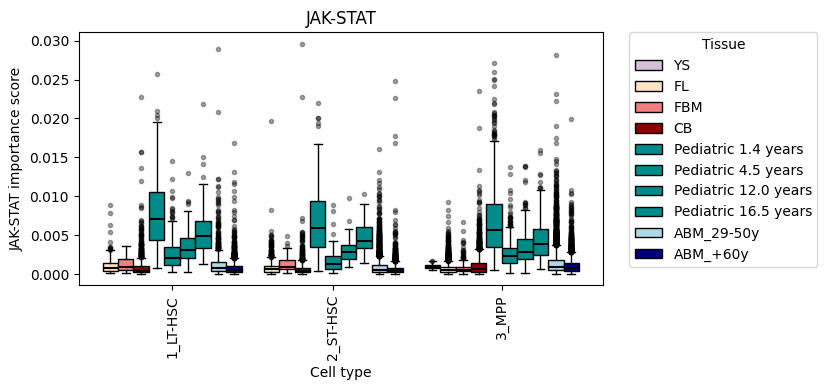

In [29]:
# JAK/STAT: LT-HSC, ST-HSC, MPP, LMPP, CLP, GMP
make_barplot_by_pediatric_donor(pert_data, 
             gp = 'JAK-STAT', 
             cell_types = ['1_LT-HSC', '2_ST-HSC', '3_MPP', 
                           #'4_MEMP', '9_LMPP', '10_CLP', '21_GMP',
                          ], 
             fig_size = (10,4),
             save = 'jak_stat_pbm_by_donor.pdf'             
            )